# Convolutional Neural Network (CNN)

## Use MNIST Fashion dataset and create a classifier to classify fashion clothing into categories.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
import keras

In [7]:
#read data
train_df= pd.read_csv('fashion-mnist_train.csv')
# test_data=pd.read_csv('fashion-mnist_test.csv')

In [8]:
import pandas as pd

# Load original dataset
df = pd.read_csv("fashion-mnist_train.csv")

# Take 10,000 random rows as test data
test_df = df.sample(n=10000, random_state=42)

# Save to new CSV
test_df.to_csv("fashion-mnist_test_file.csv", index=False)

print("Test file created successfully!")

Test file created successfully!


In [9]:
train_df.shape

(60000, 785)

In [10]:
test_df.shape

(10000, 785)

In [12]:
test_df = pd.read_csv("fashion-mnist_test_file.csv")
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,0,0,0,0,0,0,0,0,0,...,187,190,196,201,209,221,218,211,102,0
2,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
train_df = pd.read_csv("fashion-mnist_train.csv")
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# Extract feature values (all columns except 'label') from training dataset
x_train = train_df.drop(columns=["label"]).values  

# Extract target labels from training dataset
y_train = train_df["label"].values  

# Extract feature values (all columns except 'label') from testing dataset
x_test = test_df.drop(columns=["label"]).values  

# Extract target labels from testing dataset
y_test = test_df["label"].values  

In [21]:
# Reshape training data into 28x28 images with 1 channel (grayscale)
# -1 automatically calculates the number of samples
x_train = x_train.reshape(-1, 28, 28, 1)

# Reshape testing data into 28x28 images with 1 channel (grayscale)
x_test = x_test.reshape(-1, 28, 28, 1)

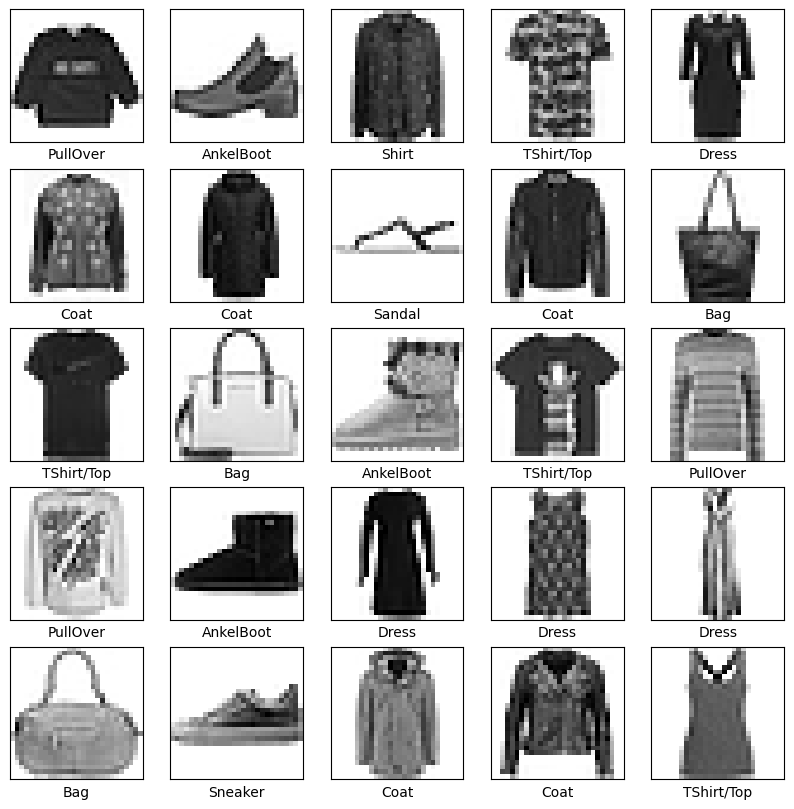

In [22]:
#Data visualization
names=['TShirt/Top','Trouser','PullOver','Dress','Coat','Sandal','Shirt','Sneaker','Bag','AnkelBoot']
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i],cmap=plt.cm.binary)
  plt.xticks([])
  plt.yticks([])
  plt.xlabel(names[y_train[i]])
  plt.grid(False)

plt.show()

In [23]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(64, (3,3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(16, activation="relu"))
model.add(Dense(10, activation="softmax"))

In [24]:
#Model compiling
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#Model training
model.fit(x=x_train, y=y_train, batch_size=32, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 [==============================] - 47s 31ms/step - loss: 1.5020 - accuracy: 0.4426 - val_loss: 1.0639 - val_accuracy: 0.6085
Epoch 2/5
1500/1500 [==============================] - 56s 37ms/step - loss: 0.6385 - accuracy: 0.7683 - val_loss: 0.4698 - val_accuracy: 0.8230
Epoch 3/5
1500/1500 [==============================] - 46s 31ms/step - loss: 0.3757 - accuracy: 0.8631 - val_loss: 0.3622 - val_accuracy: 0.8716
Epoch 4/5
1500/1500 [==============================] - 66s 44ms/step - loss: 0.3361 - accuracy: 0.8768 - val_loss: 0.3474 - val_accuracy: 0.8761
Epoch 5/5
1500/1500 [==============================] - 55s 36ms/step - loss: 0.3132 - accuracy: 0.8839 - val_loss: 0.3338 - val_accuracy: 0.8827


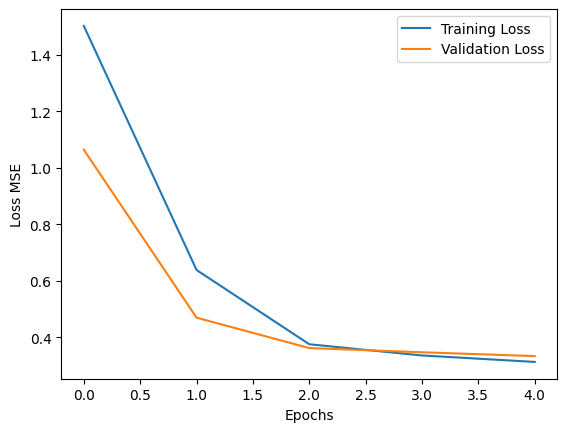

In [25]:
plt.plot(model.history.history["loss"], label="Training Loss")
plt.plot(model.history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss MSE")
plt.legend()
plt.show()

In [30]:
#Model evaluation
loss, accuracy = model.evaluate(x=x_test, y=y_test)
print("Loss : ", loss)
print("Accuracy : ", accuracy*100) 

313/313 [==============================] - 3s 8ms/step - loss: 0.3020 - accuracy: 0.8885
Loss :  0.3020486831665039
Accuracy :  88.84999752044678


In [33]:
#Testing the prediction vs Actual
predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test[:10]

print("Predicted : ", predicted_classes)
print("True : ", true_classes)

1/1 [==============================] - 0s 141ms/step
Predicted :  [7 8 8 5 9 1 2 3 6 2]
True :  [7 8 8 5 9 1 2 6 6 2]
